In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df["RoomsPerPerson"] = (
    df["AveRooms"] /
    df["Population"]
)

In [5]:
X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [7]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
ridge = Ridge()

ridge.fit(
    X_train_scaled,
    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [9]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
lr_pred = lr.predict(X_test_scaled)

ridge_pred = ridge.predict(X_test_scaled)

tree_pred = tree.predict(X_test)

In [11]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred))
    ],

    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, tree_pred)
    ]
})

print(results)

               Model      RMSE        R2
0  Linear Regression  0.745330  0.576074
1   Ridge Regression  0.745308  0.576099
2      Decision Tree  0.712504  0.612593


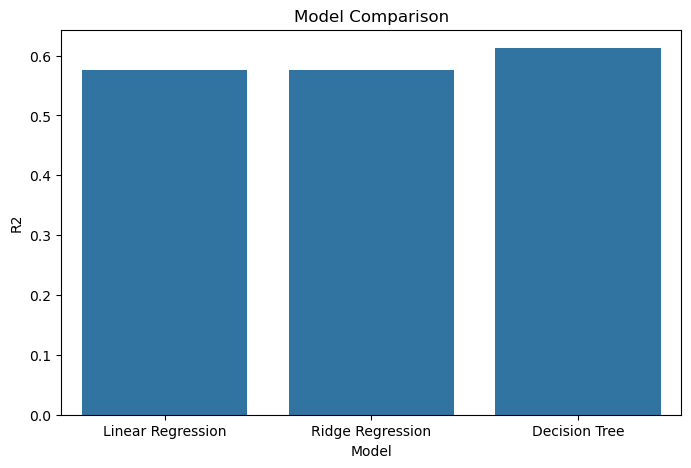

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison")

plt.show()

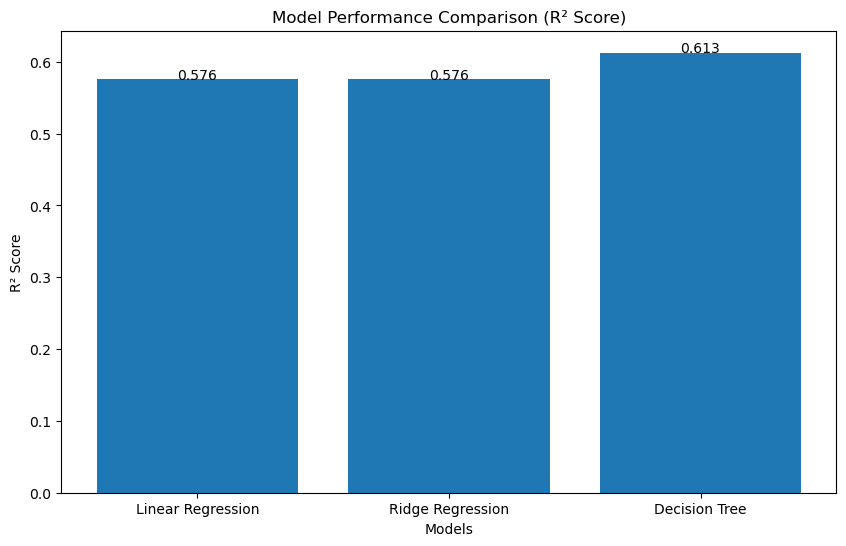

In [13]:
plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["R2"])

plt.title("Model Performance Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xlabel("Models")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),3),
        ha='center'
    )

plt.show()

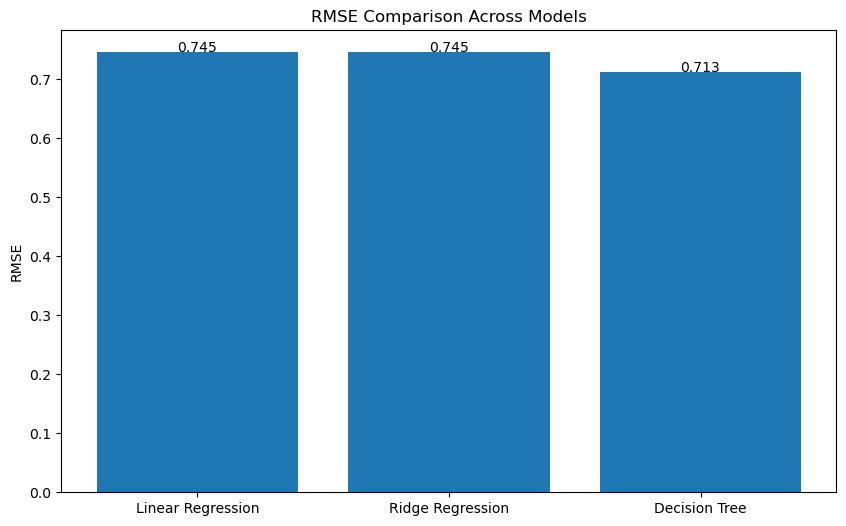

In [14]:
plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),3),
        ha='center'
    )

plt.show()

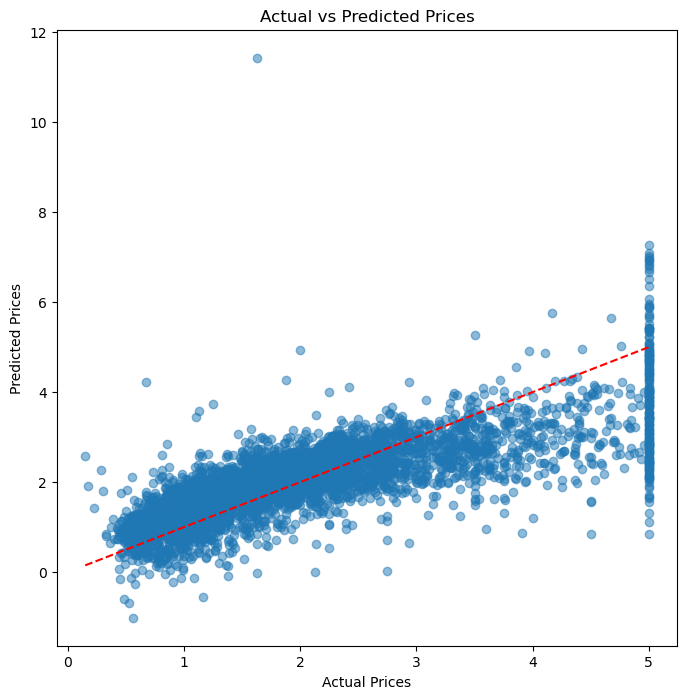

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, lr_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

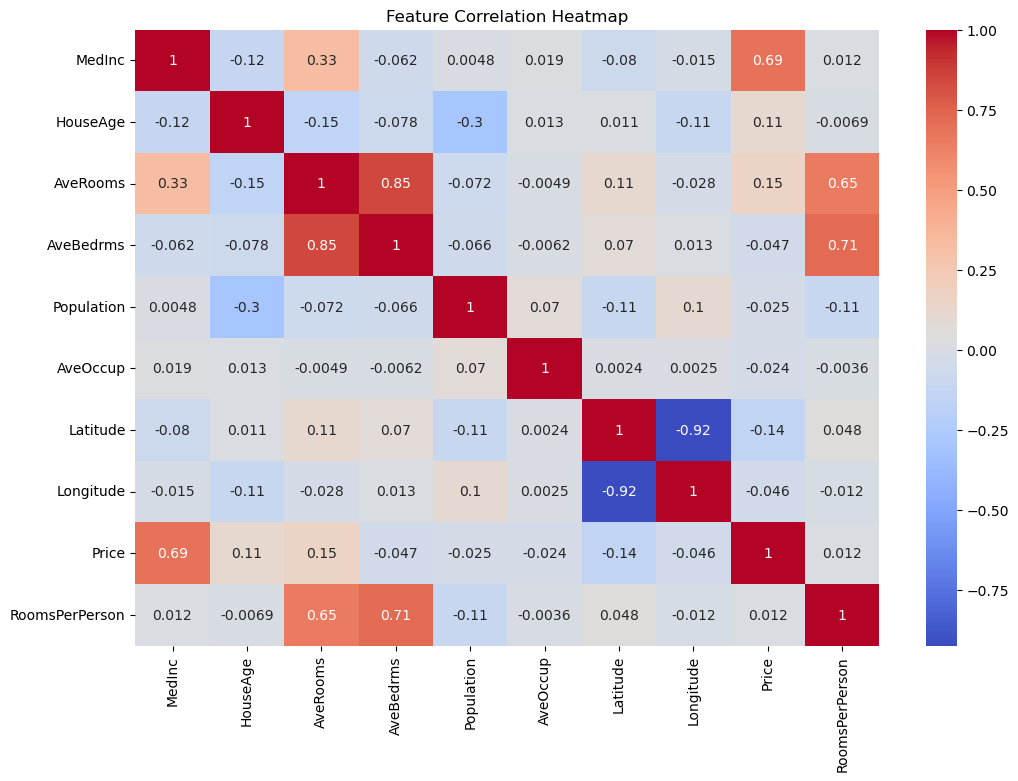

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

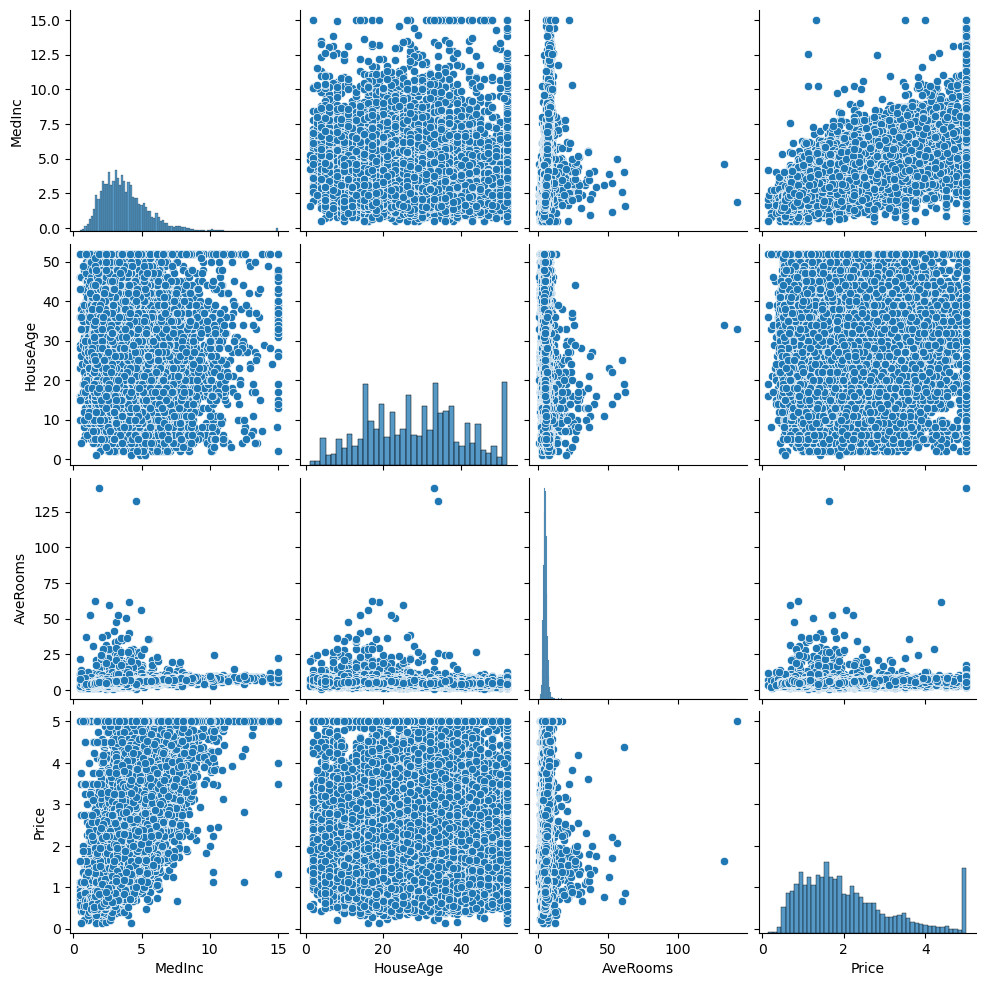

In [17]:
sns.pairplot(
    df[[
        "MedInc",
        "HouseAge",
        "AveRooms",
        "Price"
    ]]
)

plt.show()

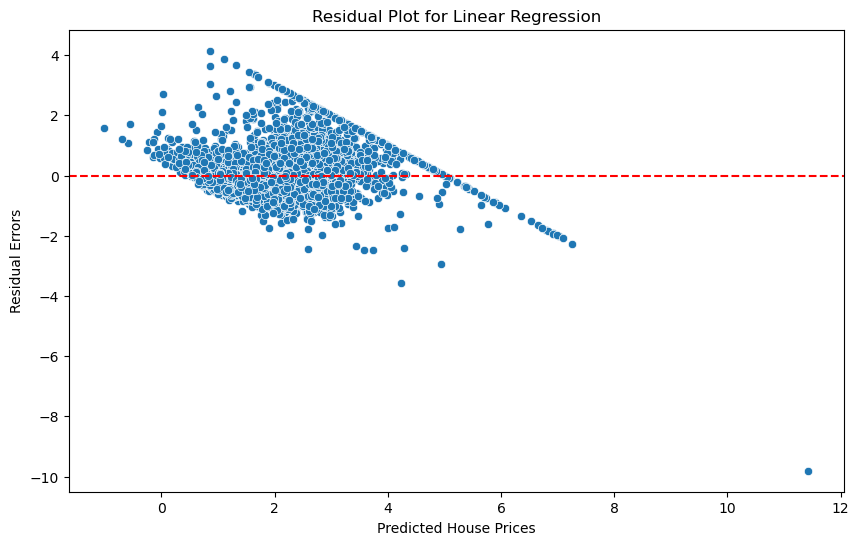

In [18]:
residuals = y_test - lr_pred

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=lr_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residual Errors")
plt.title("Residual Plot for Linear Regression")

plt.show()

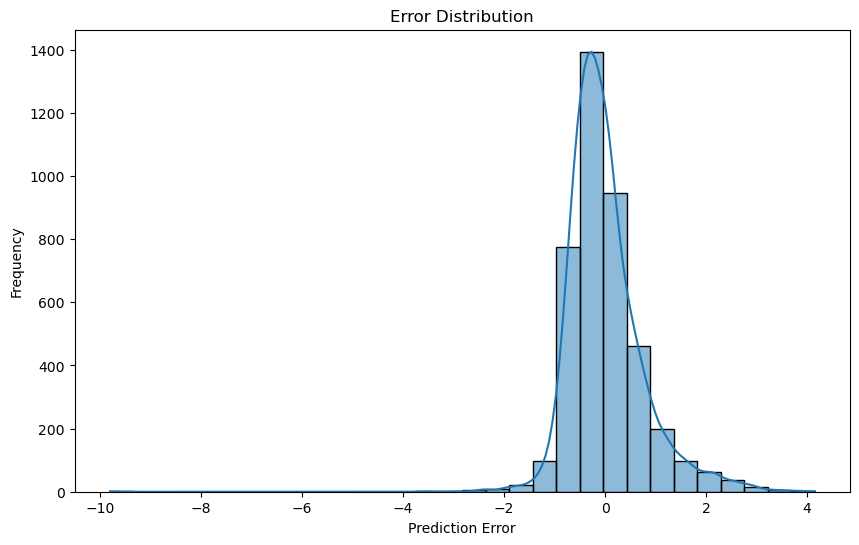

In [19]:
errors = y_test - lr_pred

plt.figure(figsize=(10,6))

sns.histplot(
    errors,
    kde=True,
    bins=30
)

plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()